In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3)

20

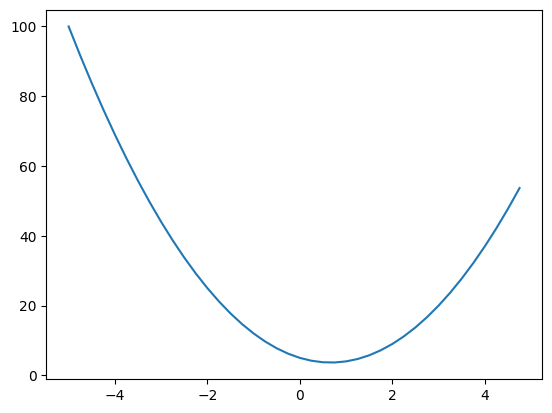

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.001
x = 3
(f(x+h)-f(x))/h

14.00300000000243

In [6]:
h = 0.001
x = 2/3
(f(x+h)-f(x))/h

0.0029999999995311555

In [7]:
h = 0.001
x = -2
(f(x+h)-f(x))/h

-15.996999999998707

In [8]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c 

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [9]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c 

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [10]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c 

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [11]:
from __future__ import annotations

class Value:
    def __init__(self, data, _children=(), _op = '', label = '') -> None:
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other: Value) -> Value:
        return Value(self.data + other.data, (self, other), '+')

    def __mul__(self, other: Value) -> Value:
        return Value(self.data * other.data, (self, other), '*')
    
    def tanh(self) -> Value:
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        return Value(t, (self,), _op = 'tanh')

In [12]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [13]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

In [14]:
from graphviz import Digraph

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir' : 'LR'}) # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s |  data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op) # add edge from prev to op

    return dot

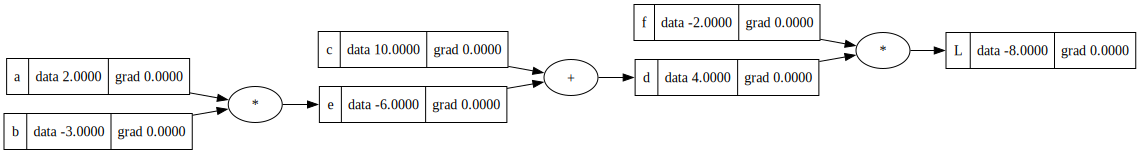

In [15]:
draw_dot(L)

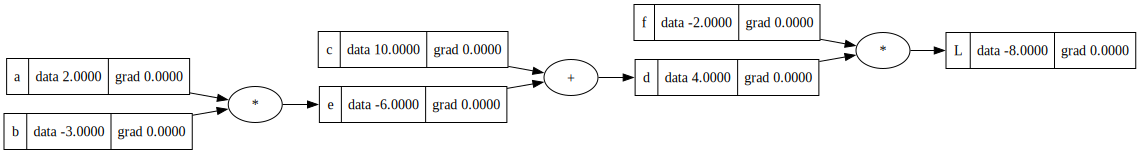

In [16]:
draw_dot(L)

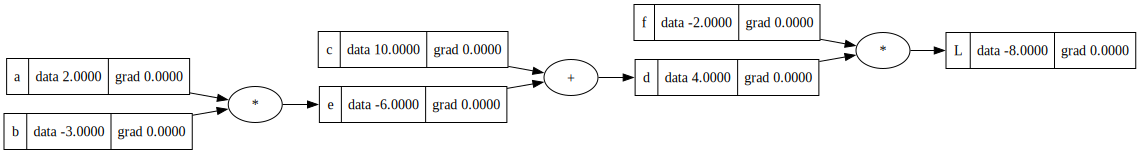

In [17]:
draw_dot(L)

In [18]:
# L.grad = 1.0

# f.grad = d.data * L.grad
# d.grad = f.data * L.grad

# c.grad = 1.0 * d.grad
# e.grad = 1.0 * d.grad

b.grad = a.data * e.grad
a.grad = b.data * e.grad

***Manual back Propagation***

In [19]:
def lol():
    h = 0.0001
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')

    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0+h, label = 'a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')

    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

In [20]:
lol()

6.000000000021544


***Repeat manual in a simple Neural Network***

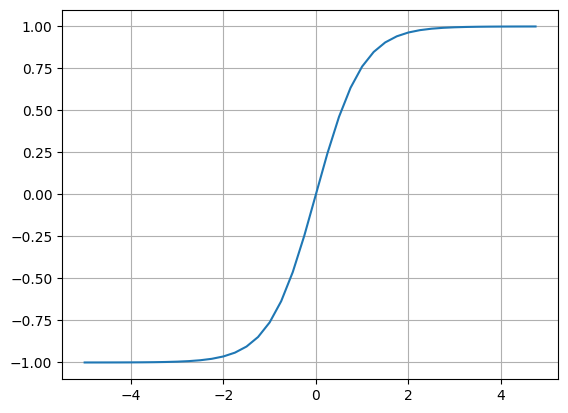

In [21]:
xs = np.arange(-5, 5, 0.25)
ys = np.tanh(xs)
plt.plot(xs, ys)
plt.grid()

In [22]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813, label='b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x2w2 + x1w1; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label ='n'

o = n.tanh(); o.label = 'o'


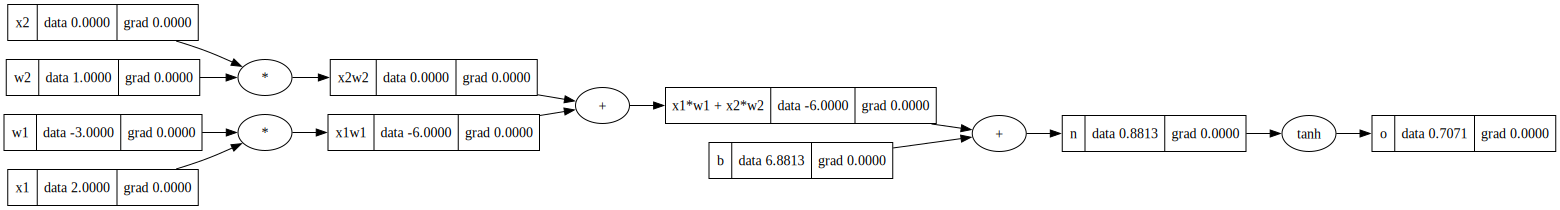

In [23]:
draw_dot(o)

In [24]:
## backprop step by step manually

o.grad = 1


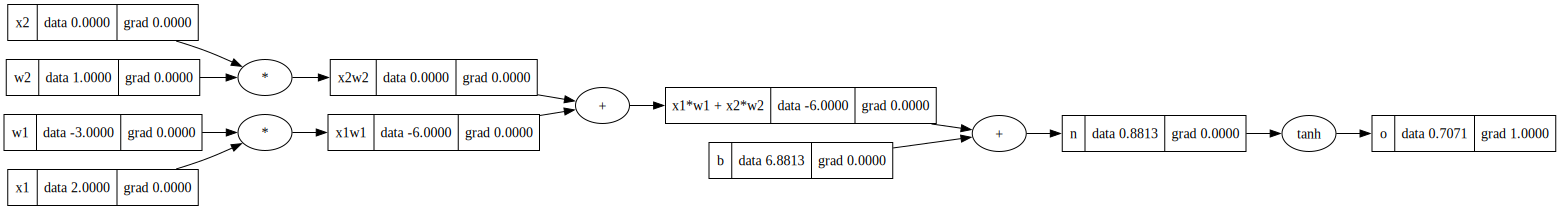

In [25]:
draw_dot(o)

In [26]:
n.grad = 1 - o.data**2 ## dtanh(x)/dx = 1 - tanh(x)**2

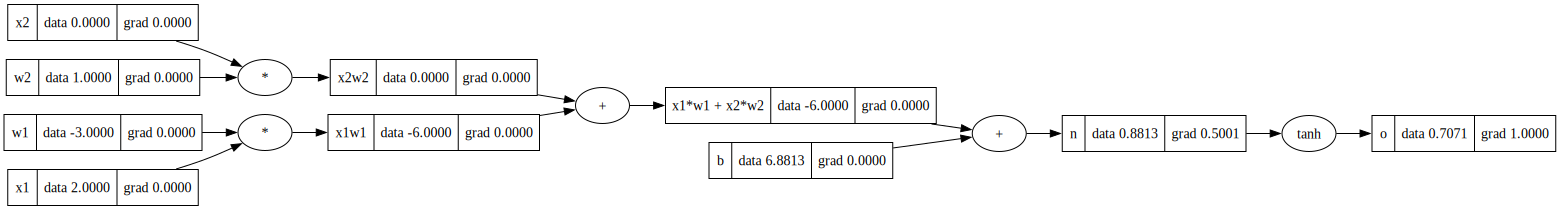

In [27]:
draw_dot(o)

In [28]:
x1w1x2w2.grad = 1.0 * n.grad
b.grad = 1.0 * n.grad

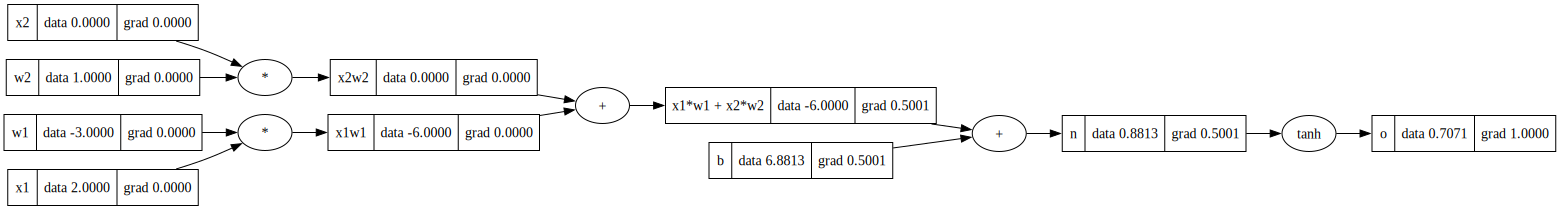

In [29]:
draw_dot(o)

In [30]:
x1w1.grad = 1.0 * x1w1x2w2.grad 
x2w2.grad = 1.0*x1w1.grad

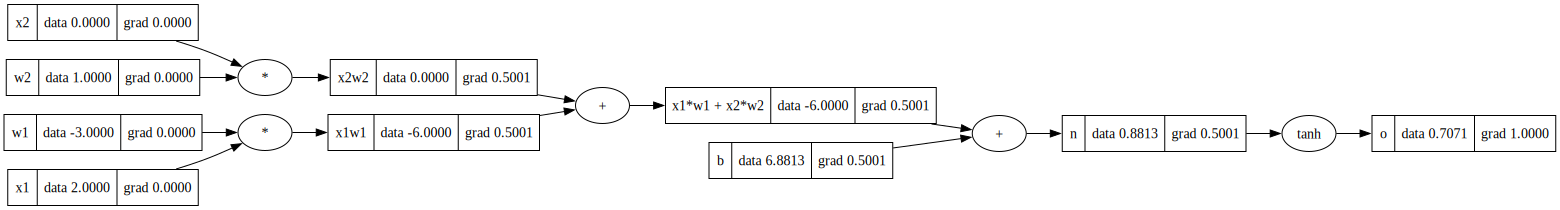

In [31]:
draw_dot(o)

In [32]:
w1.grad = x1w1.grad * x1.data 
x1.grad = x1w1.grad * w1.data 

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data

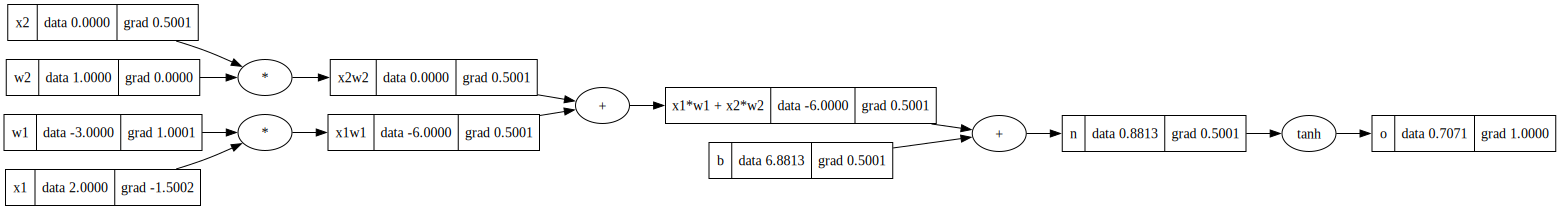

In [33]:
draw_dot(o)

***Automating Backword Prop***

In [34]:
from __future__ import annotations

class Value:
    def __init__(self, data, _children=(), _op = '', label = '') -> None:
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._backward = lambda : None
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other: Value) -> Value:
        out =  Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = out.grad
            other.grad = out.grad
        
        out._backward = _backward
        return out

    def __mul__(self, other: Value) -> Value:
        out =  Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = out.grad * other.data
            other.grad = out.grad * self.data
        
        out._backward = _backward
        return out
    
    def tanh(self) -> Value:
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out =  Value(t, (self,), _op = 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward
        return out

In [35]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813, label='b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x2w2 + x1w1; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label ='n'

o = n.tanh(); o.label = 'o'

In [36]:
o.grad = 1.0
o._backward()

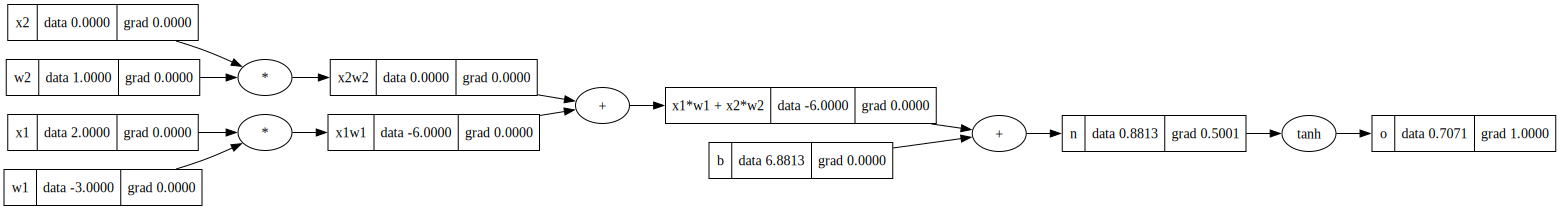

In [37]:
draw_dot(o)

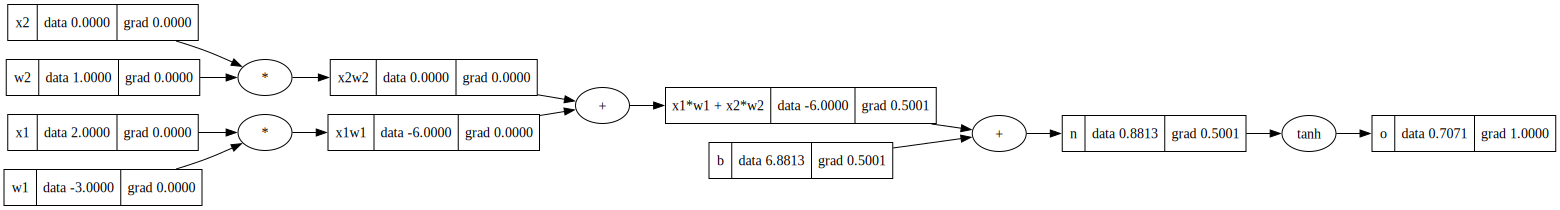

In [38]:
n._backward()
draw_dot(o)

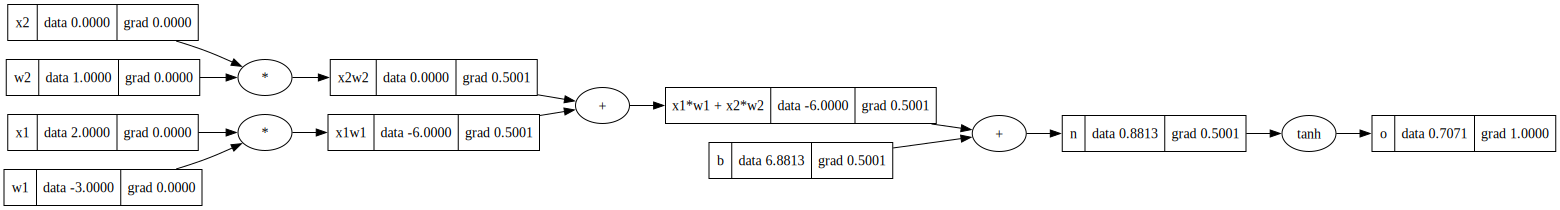

In [39]:
b._backward()
x1w1x2w2._backward()
draw_dot(o)

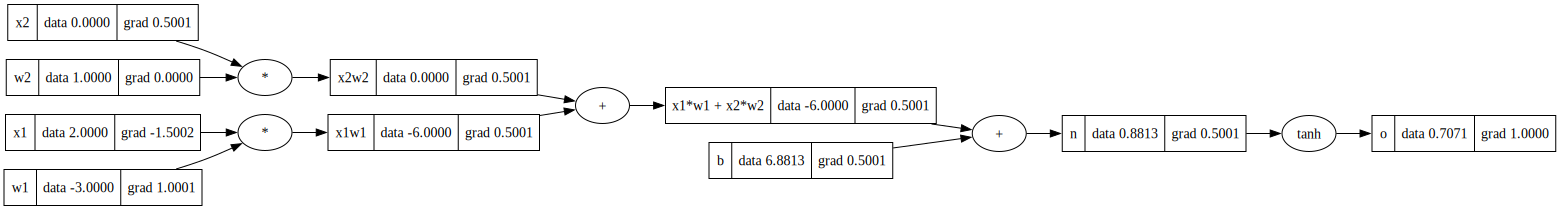

In [40]:
x1w1._backward()
x2w2._backward()
draw_dot(o)

**Building one master function using Topo sort**

In [41]:
topo = []
visited = set()

def build_topo(node):
    if node not in visited:
        visited.add(node)
        for child in node._prev:
            build_topo(child)
        topo.append(node)

build_topo(o)
topo

[Value(data=6.8813),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813000000000004),
 Value(data=0.7070699857622339)]

In [42]:
from __future__ import annotations

class Value:
    def __init__(self, data, _children=(), _op = '', label = '') -> None:
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._backward = lambda : None
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other: Value) -> Value:
        out =  Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = out.grad
            other.grad = out.grad
        
        out._backward = _backward
        return out

    def __mul__(self, other: Value) -> Value:
        out =  Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = out.grad * other.data
            other.grad = out.grad * self.data
        
        out._backward = _backward
        return out
    
    def tanh(self) -> Value:
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out =  Value(t, (self,), _op = 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    build_topo(child)
                topo.append(node)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [43]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813, label='b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x2w2 + x1w1; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label ='n'

o = n.tanh(); o.label = 'o'

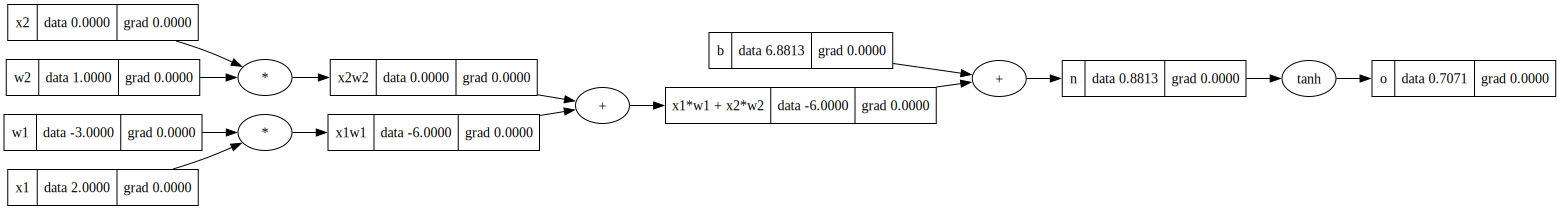

In [44]:
draw_dot(o)

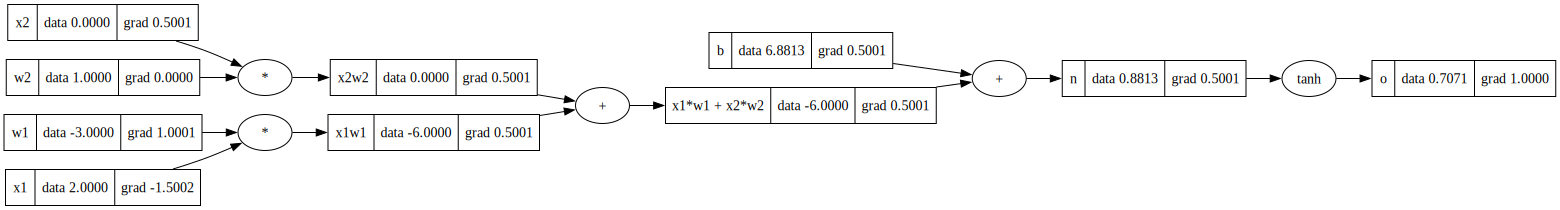

In [45]:
o.backward()
draw_dot(o)

***Small bug in backward***


**Grads needs to be accumulated**

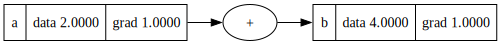

In [46]:
a = Value(2.0, label='a')
b = a + a; b.label = 'b'

b.backward()
draw_dot(b)


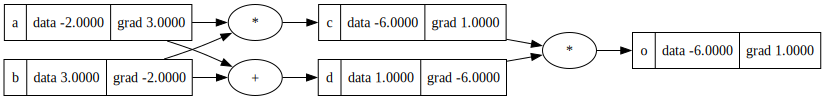

In [47]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')

c = a * b; c.label = 'c'
d = a + b; d.label = 'd'

o = c * d; o.label = 'o'

o.backward()
draw_dot(o)

In [48]:
## Fix is just accumulate grads
from __future__ import annotations

class Value:
    def __init__(self, data, _children=(), _op = '', label = '') -> None:
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._backward = lambda : None
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other: Value) -> Value:
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = _backward
        return out

    def __mul__(self, other: Value) -> Value:
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        
        out._backward = _backward
        return out
    
    def tanh(self) -> Value:
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out =  Value(t, (self,), _op = 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    build_topo(child)
                topo.append(node)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

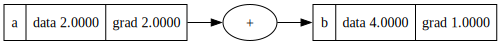

In [49]:
a = Value(2.0, label='a')
b = a + a; b.label = 'b'

b.backward()
draw_dot(b)


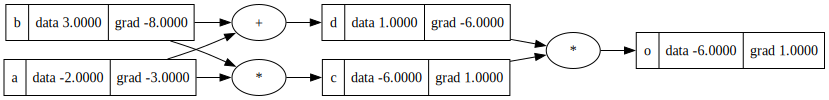

In [50]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')

c = a * b; c.label = 'c'
d = a + b; d.label = 'd'

o = c * d; o.label = 'o'

o.backward()
draw_dot(o)

***Breaking tanh into more modular***

In [51]:
## Fix is just accumulate grads
from __future__ import annotations

class Value:
    def __init__(self, data, _children=(), _op = '', label = '') -> None:
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._backward = lambda : None
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other: Value) -> Value:
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        
        out._backward = _backward
        return out

    def __mul__(self, other: Value) -> Value:
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        
        out._backward = _backward
        return out
    
    def __rmul__(self, other) -> Value:
        return self * other;

    def __sub__(self, other) -> Value:
        c = self + (-1) * other;
        return c;

    def __pow__(self, other) -> Value:
        assert isinstance(other, (int, float))
        x = self.data 
        out = Value(x**other, (self,), f"**{other}")

        def _backward():
            self.grad += other * (x ** (other-1)) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, other) -> Value:
        return self * (other**-1)
    
    
    def tanh(self) -> Value:
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out =  Value(t, (self,), _op = 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out
    
    def exp(self) -> Value:
        x = self.data 
        t = math.exp(x)
        out = Value(t, (self,), _op = 'exp')

        def _backward():
            self.grad += t * out.grad;

        out._backward = _backward;
        return out;

    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    build_topo(child)
                topo.append(node)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [54]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813, label='b')

x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x2w2 + x1w1; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label ='n'

e = (2*n).exp(); e.label = 'e'
o = (e-1)/(e+1); o.label = 'o'
o

Value(data=0.7070699857622339)

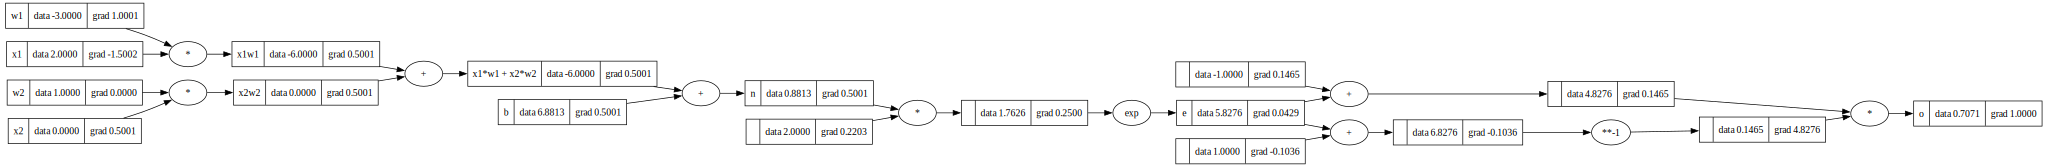

In [55]:
o.backward()
draw_dot(o)

**using Pytorch**

In [67]:
import torch 

x1 = torch.tensor([2.0]); x1.requires_grad = True
x2 = torch.tensor([0.0]); x2.requires_grad = True

w1 = torch.tensor([-3.0]); w1.requires_grad = True
w2 = torch.tensor([1.0]); w2.requires_grad = True

b = torch.tensor([6.88]); b.requires_grad = True

n = x1*w1 + x2*w2 + b 
o = torch.tanh(n)

o.backward()

print('x1', x1.grad)
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())
print('b', b.grad.item())

x1 tensor([-1.5029])
x2 0.5009716749191284
w1 1.0019433498382568
w2 0.0
b 0.5009716749191284


***Designing classes for Neuron, Layer, MLP***